In [47]:
import mo_gymnasium as mo_gym
import numpy as np
from morl_baselines.multi_policy.pareto_q_learning.pql import PQL

In [53]:
import wandb
import numpy as np
import matplotlib.pyplot as plt

def visualize_front(pareto_front):
    # 1) Build a W&B table
    pf_arr = np.array(sorted(list(pareto_front)))
    pf_table = wandb.Table(columns=["treasure", "fuel"], data=pf_arr)

    # 2) Log 2D Pareto front projections as scatter plots
    wandb.log({
        "pareto_front_fuel_treasure": wandb.plot.scatter(
            pf_table, 
            x="treasure",
            y="fuel",
            title="Pareto front of fuel vs treasure",
        )
    })
    fig, ax = plt.subplots()
    ax.scatter(pf_arr[:, 0], pf_arr[:, 1], color="black")  # single color
    ax.set_title("Pareto front of fuel vs treasure")
    ax.set_xlabel("Treasure")
    ax.set_ylabel("Fuel")

    wandb.log({"pareto_front_fuel_treasure": wandb.Image(fig)})
    plt.show()
    plt.close(fig)  # optional, avoid figure buildup



c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\spaces\box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


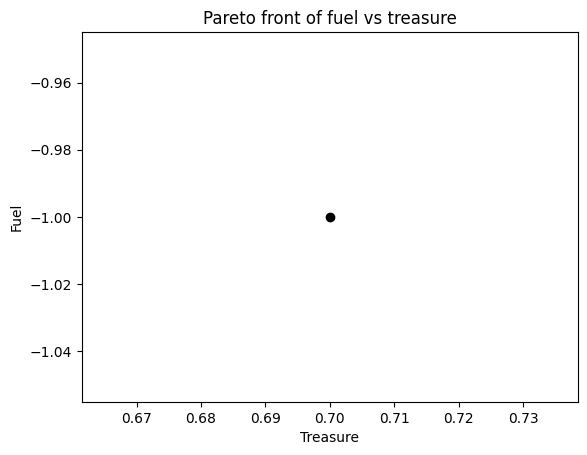

eval/cardinality,▁▁▁▁▁▁▁▁▁▁
eval/eum,▁▁▁▁▁▁▁▁▁▁
eval/hypervolume,▁▁▁▁▁▁▁▁▁▁
global_step,▁▁▂▂▃▃▃▃▄▄▅▅▆▆▆▆▇▇████
eval/cardinality,1
eval/eum,-0.14955
eval/hypervolume,0
global_step,100000


In [ ]:
env = mo_gym.make("deep-sea-treasure-v0")
eval_env = mo_gym.make("deep-sea-treasure-v0")

ref_point = np.array([0, -1])

TOTAL_TIMESTEPS = 1e5

agent = PQL(
    env=env,
    ref_point=ref_point,
    initial_epsilon=1.0,
    gamma=0.99,
    epsilon_decay_steps=TOTAL_TIMESTEPS,
    final_epsilon=0,
    seed=42,
    log=True,
)


pf = agent.train(
    total_timesteps=TOTAL_TIMESTEPS,
    eval_env=eval_env,
    ref_point=ref_point,
    log_every=TOTAL_TIMESTEPS / 10,
    action_eval="hypervolume",
)


visualize_front(pf)
wandb.finish()

In [61]:
visualize_front(env.unwrapped.pareto_front(0.99))

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()